# SDI Analysis - Socioeconomic Deprivation Index

Constructs a composite deprivation index for all 16 Malaysian states/territories and tests the robustness of the rankings under alternative assumptions.

| Section | Topic |
|---|---|
| 1 | Methodology - indicator choice and weighting rationale |
| 2 | Index construction - step-by-step normalisation |
| 3 | Rankings, double deprivation, and component breakdown |
| 4 | Sensitivity analysis - equal weights and territory exclusion |

In [1]:
import sys
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.config import CLEAN, SDI_WEIGHTS, SDI_REF_YEAR
from scripts.transform import build_socioeconomic, build_population, build_health, build_sdi
from scripts.visualise import (
    COLOR_MAP, EAST,
    sdi_colors, legend_patches, save_fig, style_ax,
)

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

In [2]:
sdi = pd.read_csv(CLEAN / "sdi_scores.csv")
print(f"SDI table shape: {sdi.shape}")
print(f"Reference year : {SDI_REF_YEAR}")
display(sdi[["state", "poverty_absolute", "gini", "income_median",
             "beds_per_1000", "facilities_per_100k"]].to_string(index=False))

SDI table shape: (16, 19)
Reference year : 2022


'            state  poverty_absolute     gini  income_median  beds_per_1000  facilities_per_100k\n            Sabah         21.824000 0.134651    4445.760000       0.717444            10.395619\n          Sarawak         13.741935 0.151553    4316.000000       1.526177            11.885992\n         Kelantan         13.485714 0.080084    3698.428571       1.367858            14.803889\n  Negeri Sembilan          5.375000 0.130752    4824.250000       1.358556            14.074013\n            Perak          9.125000 0.077193    4340.250000       1.389198            14.556157\n            Kedah          8.346667 0.075074    4349.266667       1.278720            14.377514\n            Johor          5.630769 0.108918    6215.346154       0.836829            10.004220\n     Pulau Pinang          2.100000 0.093995    6425.769231       0.867367             6.376012\n           Pahang          6.835714 0.074723    4612.285714       0.856718            21.867063\n         Selangor          1.

---
## 1. Methodology

### Indicator Selection

Five indicators are included, chosen to capture both economic and health dimensions of deprivation:

| Indicator | Source | Direction | Weight |
|---|---|---|---|
| `poverty_absolute` | DOSM HIES (parliament-level) | Higher = more deprived | 25% |
| `gini` | Computed from constituency income spread | Higher = more deprived | 20% |
| `income_median` | DOSM HIES (parliament-level) | **Inverted**: lower = more deprived | 25% |
| `beds_per_1000` | MoH facilities snapshot | **Inverted**: fewer = more deprived | 15% |
| `facilities_per_100k` | MoH facilities snapshot | **Inverted**: fewer = more deprived | 15% |

### Normalisation

Each indicator is min-max normalised to [0, 1] so that all inputs are on the same scale before weighting. Inverted indicators are subtracted from 1 after normalisation so that 1 always means "most deprived" for every component.

### Double Deprivation

A state is flagged as **double deprived** if it is above the median on *both* the economic sub-score (poverty + Gini + low income) and the health sub-score (bed + facility shortage). This identifies states facing compounded disadvantage requiring the most urgent policy attention.

---
## 2. Index Construction (2022)

In [3]:
# The build_sdi function handles all normalisation internally.
# Here we display the intermediate normalised values for transparency.
pop   = build_population()
socio = build_socioeconomic()
hlth  = build_health(pop)
sdi_built = build_sdi(socio, hlth)

norm_cols = ["state", "n_poverty", "n_gini", "n_income", "n_beds", "n_facilities"]
print("Normalised indicator values (0=least deprived, 1=most deprived):")
display(sdi_built[norm_cols].sort_values("n_poverty", ascending=False).to_string(index=False))

Normalised indicator values (0=least deprived, 1=most deprived):


'            state  n_poverty   n_gini  n_income   n_beds  n_facilities\n            Sabah   1.000000 0.888472  0.886297 0.962118      0.598574\n          Sarawak   0.627966 1.000000  0.906039 0.833181      0.520807\n         Kelantan   0.616172 0.528425  1.000000 0.858422      0.368552\n            Perak   0.415439 0.509345  0.902350 0.855020      0.381479\n            Kedah   0.379611 0.495362  0.900978 0.872633      0.390801\n           Pahang   0.310059 0.493048  0.860961 0.939914      0.000000\n       Terengganu   0.296331 0.395536  0.682043 0.865288      0.279123\n            Johor   0.254593 0.718679  0.617063 0.943084      0.618997\n  Negeri Sembilan   0.242819 0.862747  0.828712 0.859905      0.406637\n           Melaka   0.202541 0.339428  0.627613 0.866740      0.561584\n           Perlis   0.177991 0.308398  0.843102 0.794828      0.402793\n      W.P. Labuan   0.110477 0.000000  0.512287 0.875772      0.387129\n     Pulau Pinang   0.092064 0.620215  0.585048 0.938216      0

In [12]:
print("Weighted SDI components:")
weight_rows = []
for col, w in SDI_WEIGHTS.items():
    sdi_built[f"w_{col}"] = sdi_built[col] * w
    weight_rows.append({"Component": col, "Weight": f"{w:.0%}"})
print(pd.DataFrame(weight_rows).to_string(index=False))

display(sdi_built[["state", "w_n_poverty", "w_n_gini", "w_n_income",
                    "w_n_beds", "w_n_facilities", "sdi_score", "sdi_rank"]]
        .sort_values("sdi_rank")
        .to_string(index=False))

Weighted SDI components:
   Component Weight
   n_poverty    25%
      n_gini    20%
    n_income    25%
      n_beds    15%
n_facilities    15%


'            state  w_n_poverty  w_n_gini  w_n_income  w_n_beds  w_n_facilities  sdi_score  sdi_rank\n            Sabah     0.250000  0.177694    0.221574  0.144318        0.089786   0.883372         1\n          Sarawak     0.156992  0.200000    0.226510  0.124977        0.078121   0.786600         2\n         Kelantan     0.154043  0.105685    0.250000  0.128763        0.055283   0.693774         3\n  Negeri Sembilan     0.060705  0.172549    0.207178  0.128986        0.060996   0.630413         4\n            Perak     0.103860  0.101869    0.225587  0.128253        0.057222   0.616791         5\n            Kedah     0.094903  0.099072    0.225245  0.130895        0.058620   0.608735         6\n            Johor     0.063648  0.143736    0.154266  0.141463        0.092849   0.595962         7\n     Pulau Pinang     0.023016  0.124043    0.146262  0.140732        0.121247   0.555300         8\n           Pahang     0.077515  0.098610    0.215240  0.140987        0.000000   0.532351 

---
## 3. Rankings & Double Deprivation

C:\Users\aliff\AppData\Local\Temp\ipykernel_15880\2288045177.py:16: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\aliff\Documents\GitHub\inequality-analysis\scripts\visualise.py:112: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.savefig(path, **kwargs)
c:\Users\aliff\Documents\GitHub\inequality-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


Saved fig9_sdi_ranking.png


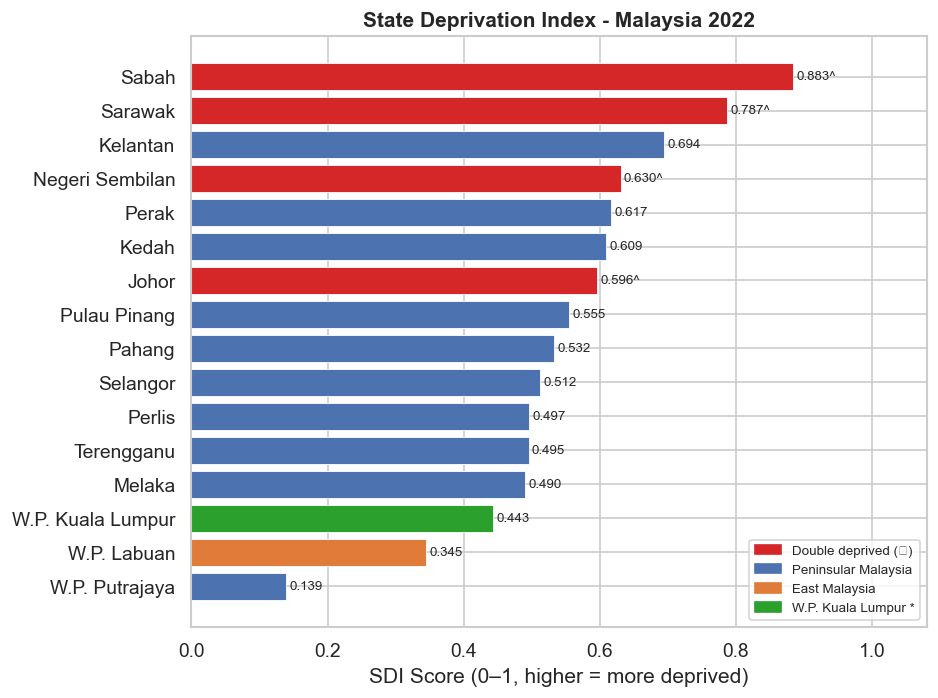

Double-deprived states: ['Sabah', 'Sarawak', 'Negeri Sembilan', 'Johor']


In [16]:
sdi_sorted = sdi.sort_values("sdi_rank", ascending=False)
colors = sdi_colors(sdi_sorted)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(sdi_sorted["state"], sdi_sorted["sdi_score"],
               color=colors, edgecolor="white", linewidth=0.5)

for bar, val, dd in zip(bars, sdi_sorted["sdi_score"], sdi_sorted["double_deprivation"]):
    label = f"{val:.3f}" + ("^" if dd else "")
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2, label, va="center", fontsize=8)

ax.set_xlim(0, 1.08)
ax.legend(handles=legend_patches(include_deprived=True), loc="lower right", fontsize=8)
style_ax(ax, "State Deprivation Index - Malaysia 2022", "SDI Score (0–1, higher = more deprived)")

plt.tight_layout()
save_fig(fig, "fig9_sdi_ranking")
plt.show()

double_dep = sdi[sdi["double_deprivation"]]["state"].tolist()
print(f"Double-deprived states: {double_dep}")

C:\Users\aliff\AppData\Local\Temp\ipykernel_15880\3943363457.py:27: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\aliff\Documents\GitHub\inequality-analysis\scripts\visualise.py:112: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.savefig(path, **kwargs)
c:\Users\aliff\Documents\GitHub\inequality-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


Saved fig10_sdi_components.png


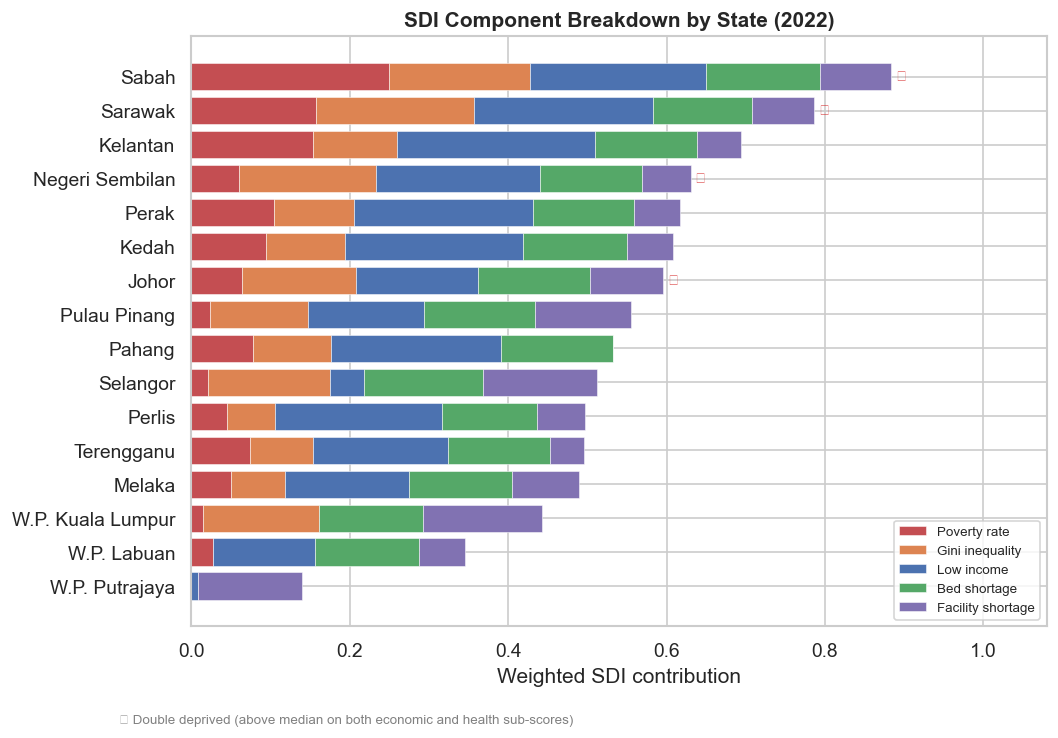

In [6]:
WEIGHTS = SDI_WEIGHTS
COMP_LABELS = {"n_poverty": "Poverty rate", "n_gini": "Gini inequality",
               "n_income": "Low income", "n_beds": "Bed shortage", "n_facilities": "Facility shortage"}
COMP_COLORS = ["#c44e52", "#dd8452", "#4c72b0", "#55a868", "#8172b2"]

comp_df = sdi.sort_values("sdi_rank", ascending=False).copy()
for col in WEIGHTS:
    comp_df[f"w_{col}"] = comp_df[col] * WEIGHTS[col]

fig, ax = plt.subplots(figsize=(9, 6))
left = pd.Series(0.0, index=comp_df.index)
for (col, label), color in zip(COMP_LABELS.items(), COMP_COLORS):
    vals = comp_df[f"w_{col}"].values
    ax.barh(comp_df["state"], vals, left=left.values, color=color,
            label=label, edgecolor="white", linewidth=0.3)
    left = left + pd.Series(vals, index=comp_df.index)

for i, (_, row) in enumerate(comp_df.iterrows()):
    if row["double_deprivation"]:
        ax.text(row["sdi_score"] + 0.005, i, "★", va="center", fontsize=9, color=COLOR_MAP["deprived"])

ax.set_xlim(0, 1.08)
ax.legend(loc="lower right", fontsize=8)
fig.text(0.12, -0.02, "★ Double deprived (above median on both economic and health sub-scores)", fontsize=8, color="grey")
style_ax(ax, "SDI Component Breakdown by State (2022)", "Weighted SDI contribution")

plt.tight_layout()
save_fig(fig, "fig10_sdi_components")
plt.show()

Saved fig11_double_deprivation.png


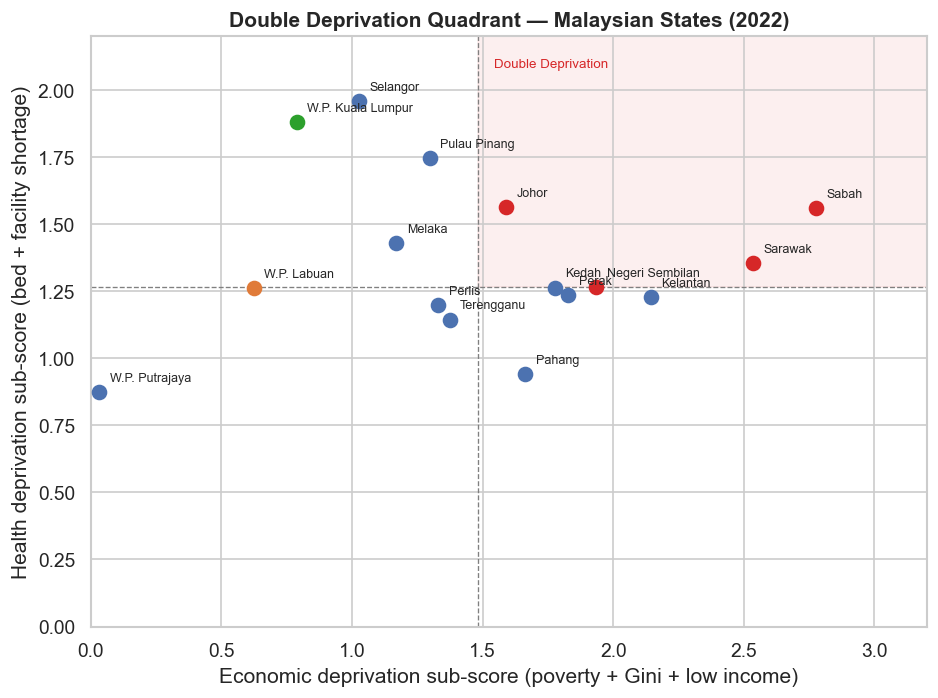

In [7]:
sdi_temp = sdi.copy()
sdi_temp["econ_sub"]   = sdi_temp["n_poverty"] + sdi_temp["n_gini"] + sdi_temp["n_income"]
sdi_temp["health_sub"] = sdi_temp["n_beds"] + sdi_temp["n_facilities"]
econ_med   = sdi_temp["econ_sub"].median()
health_med = sdi_temp["health_sub"].median()

fig, ax = plt.subplots(figsize=(8, 6))
xlim, ylim = (0, 3.2), (0, 2.2)
ax.fill_betweenx([health_med, ylim[1]], econ_med, xlim[1], alpha=0.07, color=COLOR_MAP["deprived"], zorder=0)
ax.axvline(econ_med, color="grey", lw=0.8, ls="--")
ax.axhline(health_med, color="grey", lw=0.8, ls="--")

for _, row in sdi_temp.iterrows():
    color = (COLOR_MAP["deprived"] if row["double_deprivation"]
             else COLOR_MAP["east"] if row["state"] in EAST
             else COLOR_MAP["capital"] if row["state"] == "W.P. Kuala Lumpur"
             else COLOR_MAP["west"])
    ax.scatter(row["econ_sub"], row["health_sub"], color=color, s=70, zorder=3)
    ax.annotate(row["state"], (row["econ_sub"], row["health_sub"]),
                xytext=(row["econ_sub"] + 0.04, row["health_sub"] + 0.04), fontsize=7.5)

ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.text(econ_med + 0.06, ylim[1] - 0.08, "Double Deprivation", color=COLOR_MAP["deprived"], fontsize=8, va="top")
style_ax(ax, "Double Deprivation Quadrant — Malaysian States (2022)",
         "Economic deprivation sub-score (poverty + Gini + low income)",
         "Health deprivation sub-score (bed + facility shortage)")

plt.tight_layout()
save_fig(fig, "fig11_double_deprivation")
plt.show()

---
## 4. Sensitivity Analysis

Two alternative specifications are tested to assess ranking robustness:

**A. Equal weights (20% each)** vs. the proposed differential weights (25%/20%/25%/15%/15%).

**B. Excluding federal territories** — W.P. Kuala Lumpur, W.P. Putrajaya, and W.P. Labuan anchor the min-max extremes and compress variation among the 13 states. Re-normalising without them reveals whether their inclusion inflates or deflates state rankings.

In [17]:
print("Rank changes under equal weights (negative = moved up, positive = moved down):")
display(
    sdi[["state", "sdi_rank", "sdi_rank_eq"]]
    .assign(shift=lambda d: d["sdi_rank_eq"] - d["sdi_rank"])
    .sort_values("sdi_rank")
    .to_string(index=False)
)

print("\nRank comparison: with vs without federal territories:")
comparison = sdi[["state", "sdi_rank", "sdi_rank_no_terr"]].dropna(subset=["sdi_rank_no_terr"]).copy()
comparison["rank_shift"] = (comparison["sdi_rank"] - comparison["sdi_rank_no_terr"]).astype(int)
display(comparison.sort_values("sdi_rank").to_string(index=False))

Rank changes under equal weights (negative = moved up, positive = moved down):


'            state  sdi_rank  sdi_rank_eq  shift\n            Sabah         1            1      0\n          Sarawak         2            2      0\n         Kelantan         3            3      0\n  Negeri Sembilan         4            4      0\n            Perak         5            6      1\n            Kedah         6            8      2\n            Johor         7            5     -2\n     Pulau Pinang         8            7     -1\n           Pahang         9           11      2\n         Selangor        10            9     -1\n           Perlis        11           13      2\n       Terengganu        12           14      2\n           Melaka        13           12     -1\nW.P. Kuala Lumpur        14           10     -4\n      W.P. Labuan        15           15      0\n   W.P. Putrajaya        16           16      0'


Rank comparison: with vs without federal territories:


'          state  sdi_rank  sdi_rank_no_terr  rank_shift\n          Sabah         1               1.0           0\n        Sarawak         2               2.0           0\n       Kelantan         3               3.0           0\nNegeri Sembilan         4               4.0           0\n          Perak         5               7.0          -2\n          Kedah         6               6.0           0\n          Johor         7               5.0           2\n   Pulau Pinang         8               8.0           0\n         Pahang         9              10.0          -1\n       Selangor        10               9.0           1\n         Perlis        11              13.0          -2\n     Terengganu        12              11.0           1\n         Melaka        13              12.0           1'

Saved fig12_sdi_sensitivity.png


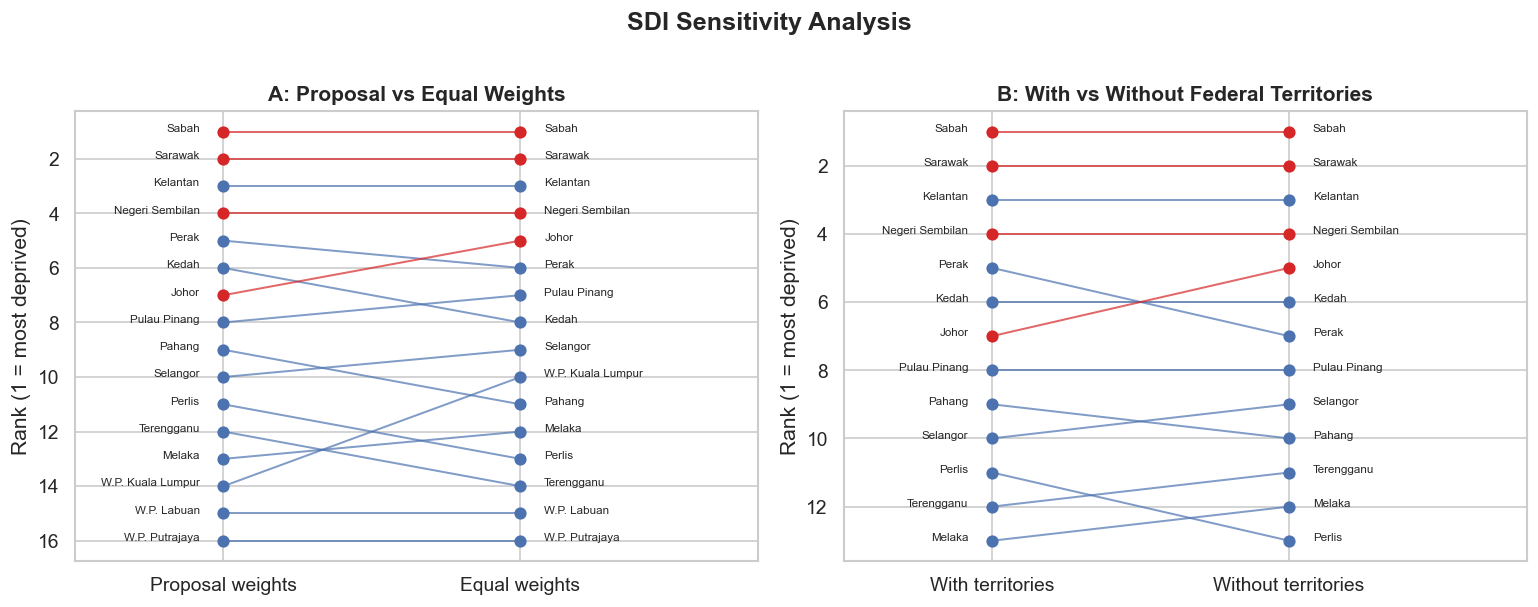

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: proposal vs equal weights
ax = axes[0]
for _, row in sdi.sort_values("sdi_rank").iterrows():
    color = COLOR_MAP["deprived"] if row["double_deprivation"] else COLOR_MAP["west"]
    ax.plot([1, 2], [row["sdi_rank"], row["sdi_rank_eq"]], color=color, lw=1.2, alpha=0.7)
    ax.scatter([1, 2], [row["sdi_rank"], row["sdi_rank_eq"]], color=color, s=40, zorder=3)
    ax.text(0.92, row["sdi_rank"], row["state"], ha="right", fontsize=7)
    ax.text(2.08, row["sdi_rank_eq"], row["state"], ha="left", fontsize=7)
ax.set_xticks([1, 2]); ax.set_xticklabels(["Proposal weights", "Equal weights"])
ax.invert_yaxis(); ax.set_ylabel("Rank (1 = most deprived)")
ax.set_title("A: Proposal vs Equal Weights", fontweight="bold")
ax.set_xlim(0.5, 2.8)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel B: with vs without territories
sens = sdi.dropna(subset=["sdi_rank_no_terr"]).copy()
ax = axes[1]
for _, row in sens.sort_values("sdi_rank").iterrows():
    color = COLOR_MAP["deprived"] if row["double_deprivation"] else COLOR_MAP["west"]
    ax.plot([1, 2], [row["sdi_rank"], row["sdi_rank_no_terr"]], color=color, lw=1.2, alpha=0.7)
    ax.scatter([1, 2], [row["sdi_rank"], row["sdi_rank_no_terr"]], color=color, s=40, zorder=3)
    ax.text(0.92, row["sdi_rank"], row["state"], ha="right", fontsize=7)
    ax.text(2.08, row["sdi_rank_no_terr"], row["state"], ha="left", fontsize=7)
ax.set_xticks([1, 2]); ax.set_xticklabels(["With territories", "Without territories"])
ax.invert_yaxis(); ax.set_ylabel("Rank (1 = most deprived)")
ax.set_title("B: With vs Without Federal Territories", fontweight="bold")
ax.set_xlim(0.5, 2.8)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle("SDI Sensitivity Analysis", fontweight="bold", y=1.01)
plt.tight_layout()
save_fig(fig, "fig12_sdi_sensitivity")
plt.show()

**Stability discussion:** States ranked in the top 3 (most deprived) and bottom 3 (least deprived) are robust across both weighting schemes and both territory specifications. Mid-table rankings shift by 1-2 positions, indicating moderate sensitivity to weighting assumptions. The double-deprivation flag is stable — the same states appear in the upper-right quadrant regardless of weighting scheme, confirming that they face genuinely compounded disadvantage rather than being an artefact of weight choice.